# BayesRTMMRL Monte Carlo 采样梯度方向分析

这个 notebook 用于复现实验型梯度分析：固定同一张图像，重复进行多次独立随机采样前向传播和反向传播，提取 BayesRTMMRL 中不同参数块的梯度，并计算两两余弦相似度矩阵。

分析目标：

1. 衡量 Monte Carlo 采样是否导致梯度方向不一致；
2. 分别观察 `R` 侧 Bayesian image representation projection、`T` 侧 Bayesian text projection，以及 MMRL representation learner 的梯度稳定性；
3. 生成热力图、CSV、PNG，便于放进论文附录或实验记录。

> 建议把本文件放到项目的 `MMRL/notebooks/` 下运行，或者在下面配置 `PROJECT_ROOT` 指向 `MMRL/` 目录。

## 0. BayesRTMMRL 训练流程梳理

根据当前项目代码，BayesRTMMRL 的训练流程可概括为：

- `BayesRTMMRLMethod` 注册名为 `"BayesRTMMRL"`，其模型类为 `BayesRTMMRLModel`。
- `build()` 中会加载 MMRL 版 CLIP 与原始 CLIP；原始 CLIP 用于构造 zero-shot text features 和 image reference features。
- 可训练参数主要包括：
  - `representation_learner`
  - `image_encoder.bayes_proj_rep`，当 `BAYES_R_ENABLED=True`
  - `text_posterior`，当 `BAYES_T_ENABLED=True`
- `forward_train()` 中，先用原始 CLIP image encoder 得到 `img_ref`，再调用 `self.model.forward_joint(..., num_samples=N_MC_TRAIN, use_posterior_mean=False)` 走随机后验采样路径。
- `forward_joint()` 中：
  - 文本侧可从 `text_posterior` 采样 text projection；
  - 图像 representation 分支可从 `bayes_proj_rep` 采样 projection；
  - 生成 `logits_main_stack` 和 `logits_rep_stack`，形状为 `[S, B, C]`。
- 训练损失由两路 expected CE、图像/文本 cosine regularization、R/T KL 项组成。
- `OnlineExecutor.forward_backward()` 在每个 batch 前设置 KL normalizer，并按 warmup 规则设置 `kl_beta`，然后执行 AMP 或 fp32 backward。

本 notebook 会保留这个训练图，但为了分析单次采样导致的梯度扰动，默认把 `num_samples` 设为 1，并重复做 `NUM_GRAD_SAMPLES=20` 次独立 forward/backward。

## 1. 基本配置

需要按你的本地路径修改：

- `PROJECT_ROOT`：项目中的 `MMRL/` 目录
- `DATA_ROOT`：数据集根目录
- `DATASET_NAME`：用于取固定图像的数据集，例如 `eurosat`
- `MODEL_DIR`：可选；填入训练好的 checkpoint 目录时，会先加载模型再分析梯度

In [1]:
from pathlib import Path
import os

# ===== 必改：指向你的 MMRL 目录 =====
PROJECT_ROOT = Path("/root/autodl-tmp/MMRL").expanduser().resolve()

# ===== 数据与实验配置 =====
DATA_ROOT = Path("DATASETS").expanduser()   # 也可以写绝对路径
DATASET_NAME = "eurosat"
PROTOCOL = "FS"
SHOTS = 8
SEED = 1
BACKBONE = "ViT-B/16"

METHOD_CONFIG = "configs/methods/bayesrt_mmrl.yaml"
PROTOCOL_CONFIG = "configs/protocols/fs.yaml"
RUNTIME_CONFIG = "configs/runtime/mmrl_family.yaml"

# 可选：加载已经训练好的 BayesRTMMRL checkpoint。
# 目录通常类似：
# output_refactor/BayesRTMMRL/FS/fewshot_train/eurosat/shots_8/ViT-B-16/default/seed1
MODEL_DIR = None
LOAD_EPOCH = None

# 梯度分析配置
NUM_GRAD_SAMPLES = 20
FORCE_N_MC_PER_FORWARD = 1       # 推荐为 1：每次 backward 对应一个 posterior sample
USE_POSTERIOR_MEAN_CONTROL = False
LOSS_KEY = "total"               # 可选: "total" 或 "data_term"；data_term 更能隔离采样噪声
FIX_SINGLE_IMAGE = True
BATCH_INDEX = 0

# 输出目录
ANALYSIS_DIR = PROJECT_ROOT / "output_refactor" / "analysis"  / "gradient_analysis" / "bayesrt_mmrl"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ANALYSIS_DIR:", ANALYSIS_DIR)

PROJECT_ROOT: /root/autodl-tmp/MMRL
ANALYSIS_DIR: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl


## 2. 导入项目并构建 trainer

这里复用项目的 `run.py` 入口逻辑和 `RefactorRunner`，但不会调用 `trainer.train()`，只构建模型、数据加载器和优化器。

In [2]:
import sys
from types import SimpleNamespace

assert PROJECT_ROOT.exists(), f"PROJECT_ROOT 不存在: {PROJECT_ROOT}"
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dassl.engine import build_trainer
from dassl.utils import set_random_seed
from core.config import setup_cfg
from run import _import_runtime_modules

_import_runtime_modules()

set_random_seed(SEED)

args = SimpleNamespace(
    root=str(DATA_ROOT),
    output_dir=str(ANALYSIS_DIR / "tmp_build"),
    dataset_config_file=f"configs/datasets/{DATASET_NAME}.yaml",
    method_config_file=METHOD_CONFIG,
    protocol_config_file=PROTOCOL_CONFIG,
    runtime_config_file=RUNTIME_CONFIG,
    exp_config="",
    method="BayesRTMMRL",
    protocol=PROTOCOL,
    exec_mode="online",
    seed=SEED,
    trainer="RefactorRunner",
    eval_only=False,
    model_dir="" if MODEL_DIR is None else str(MODEL_DIR),
    load_epoch=LOAD_EPOCH,
    no_train=True,
    opts=[
        "DATASET.NUM_SHOTS", str(SHOTS),
        "DATASET.SUBSAMPLE_CLASSES", "all",
        "MODEL.BACKBONE.NAME", BACKBONE,
        "HPO.ENABLED", "False",
    ],
)

cfg = setup_cfg(args)
cfg.defrost()
cfg.HPO.ENABLED = False
cfg.freeze()

trainer = build_trainer(cfg)

if MODEL_DIR is not None:
    print(f"Loading checkpoint from: {MODEL_DIR}")
    trainer.load_model(str(MODEL_DIR), epoch=LOAD_EPOCH)

method = trainer.method
model = method.model
device = trainer.device

method.n_mc_train = int(FORCE_N_MC_PER_FORWARD)

print("device:", device)
print("method.n_mc_train forced to:", method.n_mc_train)
print("BAYES_R_ENABLED:", bool(cfg.BAYESRT_MMRL.BAYES_R_ENABLED))
print("BAYES_T_ENABLED:", bool(cfg.BAYESRT_MMRL.BAYES_T_ENABLED))
print("LOSS_KEY:", LOSS_KEY)

[WARN] optional import failed: datasets.deepdird: No module named 'datasets.deepdird'
Loading trainer: RefactorRunner
Loading dataset: EuroSAT
Reading split from /root/autodl-tmp/MMRL/DATASETS/eurosat/split_zhou_EuroSAT.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/eurosat/split_fewshot/shot_8-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  -------
Dataset    EuroSAT
# classes  10
# train_x  80
# val      40
# test     8,100
---------  -------
[BayesRTMMRL] trainable params: {'representation_learner.compound_rep_tokens_r2tproj.4.weight', 'represe

/root/autodl-tmp/MMRL/trainers/refactor_runner.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None


## 3. 取固定图像 batch

默认取训练 loader 的第一个 batch，并裁剪成单张图像，以匹配“固定一张图像，重复 20 次采样”的分析设定。

In [3]:
def _first_existing_attr(obj, names):
    for name in names:
        if hasattr(obj, name):
            value = getattr(obj, name)
            if value is not None:
                return value
    return None

def get_train_loader(trainer):
    candidates = [
        "train_loader_x",
        "train_loader",
        "train_loader_u",
    ]
    loader = _first_existing_attr(trainer, candidates)
    if loader is not None:
        return loader

    dm = getattr(trainer, "dm", None)
    if dm is not None:
        loader = _first_existing_attr(dm, candidates)
        if loader is not None:
            return loader

    raise RuntimeError(
        "找不到训练 dataloader。请检查 trainer.train_loader_x 或 trainer.dm.train_loader_x。"
    )

def slice_batch_to_one(batch):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v) and v.shape[0] > 0:
            out[k] = v[:1]
        else:
            out[k] = v
    return out

loader = get_train_loader(trainer)

batch = None
for idx, candidate in enumerate(loader):
    if idx == BATCH_INDEX:
        batch = candidate
        break

assert batch is not None, f"无法取得 batch index={BATCH_INDEX}"

if FIX_SINGLE_IMAGE:
    batch = slice_batch_to_one(batch)

payload = {
    "img": batch["img"].to(device),
    "label": batch["label"].to(device),
}

print("img shape:", tuple(payload["img"].shape))
print("label:", payload["label"].detach().cpu().tolist())

img shape: (1, 3, 224, 224)
label: [6]


## 4. 定义梯度采集函数

参数分组：

- `R_mean`：`image_encoder.bayes_proj_rep.posterior_mean`
- `R_rho`：`image_encoder.bayes_proj_rep.posterior_rho`，即 sigma 的可训练参数
- `T_mean`：`text_posterior.posterior_mean`，只有 `T_TRAIN_MEAN=True` 时才是参数
- `T_rho`：`text_posterior.posterior_rho`
- `representation_learner`：MMRL representation tokens / learner 参数

注意：BayesRTMMRL 的 `T` 默认通常是固定均值、只训练 posterior sigma，因此 `T_mean` 可能不存在或无梯度。

In [4]:
def named_trainable_parameters(module):
    return [(n, p) for n, p in module.named_parameters() if p.requires_grad]

def collect_param_groups(method):
    model = method.model
    groups = {}

    bayes_r = getattr(getattr(model, "image_encoder", None), "bayes_proj_rep", None)
    if bayes_r is not None:
        if isinstance(getattr(bayes_r, "posterior_mean", None), torch.nn.Parameter):
            groups["R_mean"] = [bayes_r.posterior_mean]
        if isinstance(getattr(bayes_r, "posterior_rho", None), torch.nn.Parameter):
            groups["R_rho"] = [bayes_r.posterior_rho]

    text_post = getattr(model, "text_posterior", None)
    if text_post is not None:
        if isinstance(getattr(text_post, "posterior_mean", None), torch.nn.Parameter):
            groups["T_mean"] = [text_post.posterior_mean]
        if isinstance(getattr(text_post, "posterior_rho", None), torch.nn.Parameter):
            groups["T_rho"] = [text_post.posterior_rho]

    rep_learner = getattr(model, "representation_learner", None)
    if rep_learner is not None:
        params = [p for _, p in named_trainable_parameters(rep_learner)]
        if params:
            groups["representation_learner"] = params

    # 兜底：如果 R 侧 Bayesian 被关掉，项目中可能训练 deterministic proj_rep
    det_visual = getattr(getattr(model, "image_encoder", None), "visual", None)
    if det_visual is not None and hasattr(det_visual, "proj_rep"):
        p = det_visual.proj_rep
        if isinstance(p, torch.nn.Parameter) and p.requires_grad:
            groups["visual_proj_rep"] = [p]

    return groups

def flatten_grad(params):
    chunks = []
    total_numel = 0
    missing = 0
    for p in params:
        total_numel += p.numel()
        if p.grad is None:
            missing += p.numel()
            continue
        chunks.append(p.grad.detach().float().reshape(-1).cpu())
    if not chunks:
        return None, {"numel": total_numel, "missing_grad_numel": missing}
    return torch.cat(chunks, dim=0), {"numel": total_numel, "missing_grad_numel": missing}

def zero_all_grads(trainer, method):
    if hasattr(trainer, "optim") and trainer.optim is not None:
        trainer.optim.zero_grad(set_to_none=True)
    else:
        method.model.zero_grad(set_to_none=True)

def forward_train_like_project(method, payload, use_posterior_mean=False, num_samples=1):
    # 等价复刻 BayesRTMMRLMethod.forward_train，但允许控制 use_posterior_mean。
    image = payload["img"].to(method.device)
    label = payload["label"].to(method.device)

    with torch.no_grad():
        img_ref = method.image_encoder_clip(image.type(method.dtype))
        img_ref = torch.nn.functional.normalize(img_ref, dim=-1)

    out = method.model.forward_joint(
        image=image,
        num_samples=int(num_samples),
        use_posterior_mean=bool(use_posterior_mean),
    )
    return method._build_train_outputs(label, img_ref, out)

param_groups = collect_param_groups(method)
print("Parameter groups:")
for name, params in param_groups.items():
    n_params = sum(p.numel() for p in params)
    print(f"  {name:24s} tensors={len(params):3d} numel={n_params:,}")

Parameter groups:
  R_mean                   tensors=  1 numel=393,216
  R_rho                    tensors=  1 numel=512
  T_rho                    tensors=  1 numel=512
  representation_learner   tensors= 29 numel=4,599,040


## 5. 重复采样并提取梯度

默认每次 backward 前都会设置不同随机种子，保证每次 posterior sample 不同，同时输入图像不变。

In [5]:
def collect_gradients(
    trainer,
    method,
    payload,
    param_groups,
    num_repeats=20,
    loss_key="total",
    num_mc_per_forward=1,
    use_posterior_mean_control=False,
    base_seed=12345,
):
    method.model.train()

    records = []
    grad_bank = {name: [] for name in param_groups}
    meta_bank = {name: [] for name in param_groups}

    for i in range(int(num_repeats)):
        seed_i = int(base_seed + i)
        torch.manual_seed(seed_i)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed_i)

        zero_all_grads(trainer, method)

        outputs = forward_train_like_project(
            method,
            payload,
            use_posterior_mean=use_posterior_mean_control,
            num_samples=num_mc_per_forward,
        )

        if loss_key not in outputs.losses:
            raise KeyError(f"loss_key={loss_key!r} 不在 outputs.losses 中。可选: {list(outputs.losses.keys())}")

        loss = outputs.losses[loss_key]
        loss.backward()

        row = {"repeat": i, "seed": seed_i, "loss_key": loss_key, "loss": float(loss.detach().cpu())}
        for k, v in outputs.losses.items():
            if torch.is_tensor(v) and v.numel() == 1:
                row[k] = float(v.detach().cpu())
        records.append(row)

        for group_name, params in param_groups.items():
            g, meta = flatten_grad(params)
            if g is not None:
                grad_bank[group_name].append(g)
            meta_bank[group_name].append(meta)

        del outputs, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return grad_bank, meta_bank, pd.DataFrame(records)

grad_bank, meta_bank, loss_df = collect_gradients(
    trainer=trainer,
    method=method,
    payload=payload,
    param_groups=param_groups,
    num_repeats=NUM_GRAD_SAMPLES,
    loss_key=LOSS_KEY,
    num_mc_per_forward=FORCE_N_MC_PER_FORWARD,
    use_posterior_mean_control=USE_POSTERIOR_MEAN_CONTROL,
    base_seed=SEED * 100000 + 17,
)

display(loss_df.head())
print(loss_df[["loss"]].describe())

,repeat,seed,loss_key,loss,loss_main,loss_rep,loss_cos_img,loss_cos_text,data_term,raw_kl_r,raw_kl_t,kl_r_term,kl_t_term,kl_beta,kl_normalizer,total
0,0,100017,total,2.778153,2.553121,2.759669,0.081088,0.245047,2.778153,1.396984e-09,3.725290e-09,1.396984e-13,7.105427e-16,1.0,1.0,2.778153
1,1,100018,total,2.714030,2.483857,2.707543,0.081088,0.245047,2.714030,1.396984e-09,3.725290e-09,1.396984e-13,7.105427e-16,1.0,1.0,2.714030
2,2,100019,total,3.204952,2.548354,4.193456,0.081088,0.245047,3.204952,1.396984e-09,3.725290e-09,1.396984e-13,7.105427e-16,1.0,1.0,3.204952
3,3,100020,total,3.184534,2.685669,3.804993,0.081088,0.245047,3.184534,1.396984e-09,3.725290e-09,1.396984e-13,7.105427e-16,1.0,1.0,3.184534
4,4,100021,total,3.045525,2.606095,3.527305,0.081088,0.245047,3.045525,1.396984e-09,3.725290e-09,1.396984e-13,7.105427e-16,1.0,1.0,3.045525


            loss
count  20.000000
mean    2.923220
std     0.292448
min     2.306365
25%     2.725736
50%     2.954171
75%     3.116329
max     3.407007


## 6. 计算两两余弦相似度矩阵与摘要指标

In [6]:
def cosine_similarity_matrix(grad_list, eps=1e-12):
    if len(grad_list) == 0:
        return None
    G = torch.stack(grad_list, dim=0).float()
    norms = G.norm(dim=1, keepdim=True).clamp_min(eps)
    G = G / norms
    return (G @ G.T).cpu().numpy()

def offdiag_values(mat):
    n = mat.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return mat[mask]

def summarize_cosine_matrix(name, mat):
    vals = offdiag_values(mat)
    return {
        "group": name,
        "n": mat.shape[0],
        "offdiag_mean": float(np.mean(vals)),
        "offdiag_std": float(np.std(vals)),
        "offdiag_min": float(np.min(vals)),
        "offdiag_q25": float(np.quantile(vals, 0.25)),
        "offdiag_median": float(np.median(vals)),
        "offdiag_q75": float(np.quantile(vals, 0.75)),
        "offdiag_max": float(np.max(vals)),
        "frac_negative": float(np.mean(vals < 0.0)),
    }

cos_mats = {}
summary_rows = []

for group_name, grads in grad_bank.items():
    mat = cosine_similarity_matrix(grads)
    if mat is None:
        continue
    cos_mats[group_name] = mat
    summary_rows.append(summarize_cosine_matrix(group_name, mat))

summary_df = pd.DataFrame(summary_rows).sort_values("offdiag_mean")
display(summary_df)

loss_csv = ANALYSIS_DIR / f"loss_records_{DATASET_NAME}_shots{SHOTS}_seed{SEED}.csv"
summary_csv = ANALYSIS_DIR / f"gradient_cosine_summary_{DATASET_NAME}_shots{SHOTS}_seed{SEED}.csv"
loss_df.to_csv(loss_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved:", loss_csv)
print("Saved:", summary_csv)

,group,n,offdiag_mean,offdiag_std,offdiag_min,offdiag_q25,offdiag_median,offdiag_q75,offdiag_max,frac_negative
2,T_rho,20,-0.003473,0.231891,-0.508862,-0.178251,-0.002350,0.170706,0.549580,0.505263
1,R_rho,20,0.004795,0.078448,-0.244396,-0.036439,0.008122,0.063456,0.178879,0.452632
3,representation_learner,20,0.657562,0.089897,0.406160,0.602360,0.661703,0.721558,0.872283,0.000000
0,R_mean,20,0.776952,0.158895,0.296742,0.709028,0.820864,0.894096,0.988247,0.000000


Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/loss_records_eurosat_shots8_seed1.csv
Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/gradient_cosine_summary_eurosat_shots8_seed1.csv


## 7. 绘制 heatmap

图的读法：

- 对角线恒为 1；
- 非对角线越接近 1，说明不同 posterior sample 得到的梯度方向越一致；
- 蓝色/负值区域表示梯度方向冲突；
- 若 `R_rho` 或 `T_rho` 出现明显低相似度或负相似度，说明对应不确定性参数的训练更容易受到 MC 采样噪声干扰。

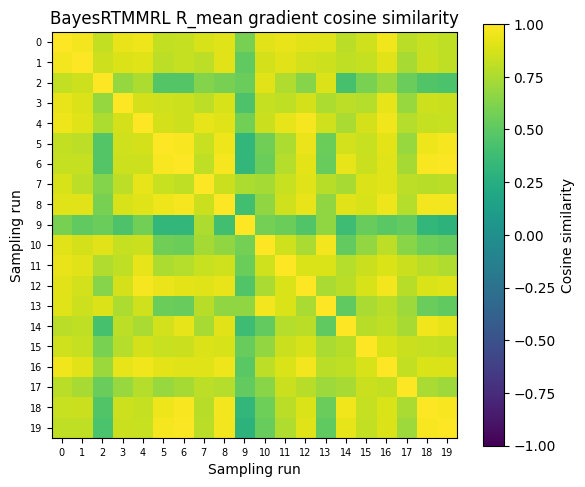

Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/heatmap_R_mean_eurosat_shots8_seed1.png


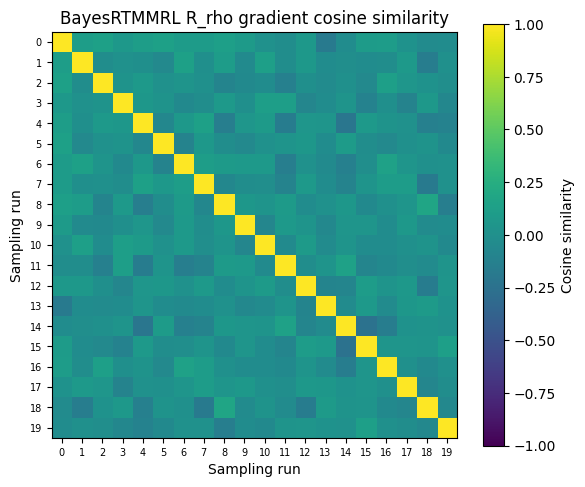

Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/heatmap_R_rho_eurosat_shots8_seed1.png


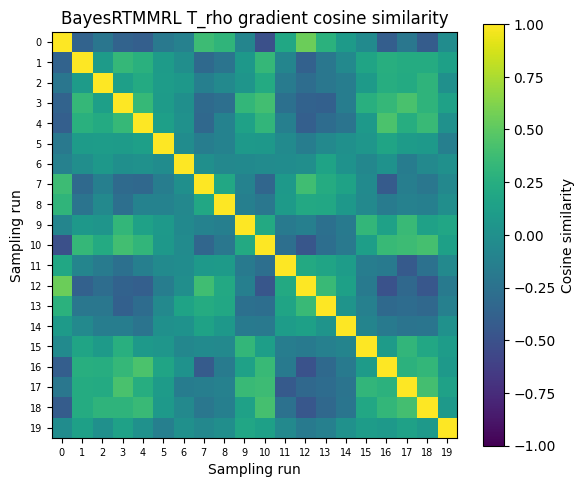

Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/heatmap_T_rho_eurosat_shots8_seed1.png


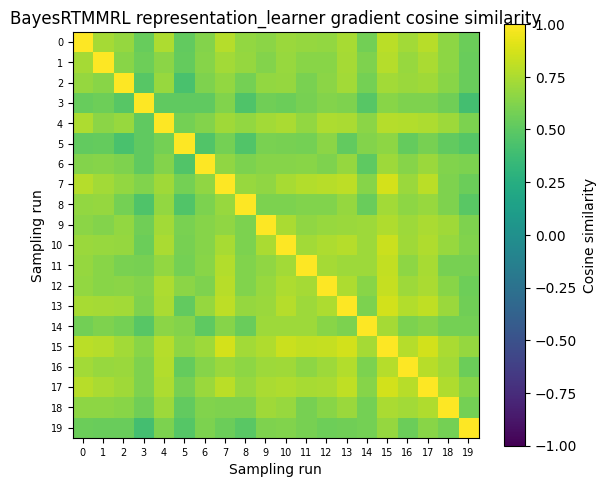

Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/heatmap_representation_learner_eurosat_shots8_seed1.png


In [7]:
def plot_heatmap(mat, title, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, vmin=-1.0, vmax=1.0, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Sampling run")
    ax.set_ylabel("Sampling run")
    ax.set_xticks(range(mat.shape[0]))
    ax.set_yticks(range(mat.shape[0]))
    ax.tick_params(axis="both", labelsize=7)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Cosine similarity")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

for group_name, mat in cos_mats.items():
    fig_path = ANALYSIS_DIR / f"heatmap_{group_name}_{DATASET_NAME}_shots{SHOTS}_seed{SEED}.png"
    plot_heatmap(
        mat,
        title=f"BayesRTMMRL {group_name} gradient cosine similarity",
        save_path=fig_path,
    )
    print("Saved:", fig_path)

## 8. 可选：把所有矩阵保存为 `.npy`

保存后可在其他脚本或论文绘图脚本中重新加载。

In [8]:
for group_name, mat in cos_mats.items():
    npy_path = ANALYSIS_DIR / f"cosmat_{group_name}_{DATASET_NAME}_shots{SHOTS}_seed{SEED}.npy"
    np.save(npy_path, mat)
    print("Saved:", npy_path)

Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/cosmat_R_mean_eurosat_shots8_seed1.npy
Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/cosmat_R_rho_eurosat_shots8_seed1.npy
Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/cosmat_T_rho_eurosat_shots8_seed1.npy
Saved: /root/autodl-tmp/MMRL/output_refactor/analysis/gradient_analysis/bayesrt_mmrl/cosmat_representation_learner_eurosat_shots8_seed1.npy


## 9. 建议报告写法

实验设置可写成：

> We fix one training image and perform 20 independent stochastic forward passes under BayesRTMMRL. In each pass, a posterior sample is drawn from the factorized Gaussian projection posterior, the training loss is backpropagated, and gradients are collected for the R-side projection posterior, the T-side projection posterior, and the representation learner. Pairwise cosine similarities are computed between the 20 gradients for each parameter block.

如果你的结果呈现：

- `R_mean` 高相似、`R_rho` 低相似：说明均值方向稳定，但方差/不确定性参数受采样噪声影响更强；
- `T_rho` 低相似：说明文本投影不确定性估计存在采样方向冲突；
- `representation_learner` 低相似：说明 MC 噪声通过后验采样反传到了 MMRL representation tokens；
- `data_term` 低相似但 `total` 相似度较高：通常是 KL 项提供了稳定的 deterministic gradient，需要在论文中明确区分“训练总梯度”和“采样诱导的数据项梯度”。